# Breast Mammography Classification — Coursework Prototype

## A1. Problem Definition & Clinical Framing

- **Body part / anatomical region:** Breast
- **Imaging modality:** Mammography (2D X-ray of breast tissue)
- **Problem type:** Binary image classification
- **Target classes:** BENIGN vs MALIGNANT mammography findings
- **Real-world question:** Can a model flag likely-malignant mammography
  findings to help prioritise radiologist review?
- **Who would use it:** Radiology departments / screening programmes — as a
  triage aid, always with human review.

**Scope statement:** This is a coursework prototype, not a diagnostic tool.
It assumes a single 2D mammography view (CC or MLO) of reasonable quality.

In [47]:
import tensorflow as tf, pathlib, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
print("imports OK, tensorflow", tf.__version__)

imports OK, tensorflow 2.20.0


## A2. Dataset Documentation

**Source:** CBIS-DDSM (Curated Breast Imaging Subset of DDSM), The Cancer
Imaging Archive — Kaggle mirror "CBIS-DDSM Breast Cancer Image Dataset"
(kaggle.com/datasets/awsaF49/cbis-ddsm-breast-cancer-image-dataset),
accessed 13 Sep 2026. Licence: CC BY-SA 3.0 (coursework use permitted).

**Structure:** labels live in CSV metadata, not in folders. Four description
files (calc/mass × train/test) carry the `pathology` column; jpeg/ holds
6,774 images in DICOM-UID-named subfolders. We match CSV rows to images by
the series UID found in both the CSV path and the folder name.

In [48]:
csv_dir = pathlib.Path.home() / "Pictures" / "archive (6)" / "csv"

train = pd.concat([pd.read_csv(csv_dir/"calc_case_description_train_set.csv"),
                   pd.read_csv(csv_dir/"mass_case_description_train_set.csv")],
                  ignore_index=True)
test = pd.concat([pd.read_csv(csv_dir/"calc_case_description_test_set.csv"),
                  pd.read_csv(csv_dir/"mass_case_description_test_set.csv")],
                 ignore_index=True)

print("train rows:", len(train), "| test rows:", len(test))
print("\ntrain counts:\n", train["pathology"].value_counts())
print("\ntest counts:\n", test["pathology"].value_counts())

train rows: 2864 | test rows: 704

train counts:
 pathology
MALIGNANT                  1181
BENIGN                     1105
BENIGN_WITHOUT_CALLBACK     578
Name: count, dtype: int64

test counts:
 pathology
BENIGN                     324
MALIGNANT                  276
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64


**Class distribution:** counts per class per split (brief requirement).
Nearly balanced (~54% malignant in train) — unlike the pneumonia dataset,
so class weights will be close to 1.0.

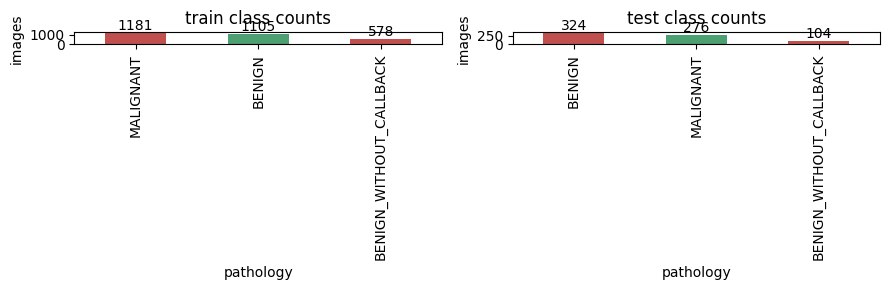

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, (name, df) in zip(axes, [("train", train), ("test", test)]):
    df["pathology"].value_counts().plot(kind="bar", ax=ax, color=["#c0504d", "#4c9f70"])
    ax.set_title(f"{name} class counts"); ax.set_ylabel("images")
    for i, v in enumerate(df["pathology"].value_counts()):
        ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout(); plt.show()

## A3. Data Preparation & Splitting

**What:** Match every CSV label row to its image file on disk, then build
model-ready TensorFlow datasets.

**Why:**
- Labels live in the CSVs; images live in jpeg/ subfolders named by DICOM
  series UID. The CSV path contains several UIDs (study, series, image), so
  we try each against the folder index until one matches; unmatched rows
  are dropped and counted.
- Images are resized to 224×224, kept 3-channel, rescaled to 0–1 inside
  the model (A4).
- The official patient-level train/test split is kept; a validation set
  (~15%) is carved from train. A leakage check verifies no patient_id
  appears in two splits.

In [ ]:
jpeg_dir = pathlib.Path.home() / "Pictures" / "archive (6)" / "jpeg"

uid_index = {}
for f in jpeg_dir.rglob("*"):
    if f.suffix.lower() in (".jpg", ".jpeg", ".png"):
        m = re.search(r"1\.3\.6\.1\.4[\d.]+", str(f.parent))
        if m:
            uid_index.setdefault(m.group(0), f)
print("indexed folders:", len(uid_index))

def uids_of(p):
    return re.findall(r"1\.3\.6\.1\.4[\d.]+", str(p))

for df in (train, test):
    df["img_path"] = df["image file path"].apply(
        lambda p: next((uid_index[u] for u in uids_of(p) if u in uid_index), None))

for name, df in [("train", train), ("test", test)]:
    found = df["img_path"].notna().sum()
    print(f"{name}: {found}/{len(df)} rows matched to an image file")

**Split & leakage handling:** rows are deduplicated by image path. Patients
appearing in both official files are removed from train. Because a patient
contributes multiple images, the validation set is carved out by PATIENT,
not by row, so no patient's images straddle two splits.

In [ ]:
def prep(df):
    df = df[df["pathology"].isin(["BENIGN", "MALIGNANT"])].copy()
    df = df.dropna(subset=["img_path"])
    df["label"] = (df["pathology"] == "MALIGNANT").astype(int)  # 0=BENIGN, 1=MALIGNANT
    return df.drop_duplicates(subset=["img_path"]).reset_index(drop=True)

train_df = prep(train)
test_df  = prep(test)
print("usable train:", len(train_df), "| usable test:", len(test_df))

overlap = set(train_df["patient_id"]) & set(test_df["patient_id"])
print("patients in both files (removed from train):", len(overlap))
train_df = train_df[~train_df["patient_id"].isin(overlap)].reset_index(drop=True)

patients = train_df.drop_duplicates(subset=["patient_id"])
p_tr, p_va = train_test_split(patients["patient_id"], test_size=0.15, random_state=42)

tr = train_df[train_df["patient_id"].isin(p_tr)]
va = train_df[train_df["patient_id"].isin(p_va)]
print(f"train: {len(tr)} rows / {tr.patient_id.nunique()} patients | "
      f"val: {len(va)} rows / {va.patient_id.nunique()} patients | test: {len(test_df)} rows")

assert not (set(tr.patient_id) & set(va.patient_id))
assert not (set(tr.patient_id) & set(test_df.patient_id))
assert not (set(va.patient_id) & set(test_df.patient_id))
print("leakage check PASSED: no patient appears in more than one split")

In [53]:
data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])
rescale = layers.Rescaling(1.0 / 255)


**Preprocessing layers:** random flip/rotation/zoom for training-time
augmentation, and 0-255 → 0-1 rescaling. Both are attached inside the model
so the exported model is self-contained (important for Part B).

In [55]:
IMG_SIZE = (224, 224)
BATCH = 32

def df_to_ds(df, shuffle):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["img_path"].astype(str).values, df["label"].values))
    if shuffle:
        ds = ds.shuffle(len(df), reshuffle_each_iteration=True)
    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, IMG_SIZE)
        return img, label
    return ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE) \
             .batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = df_to_ds(tr, shuffle=True)
val_ds   = df_to_ds(va, shuffle=False)
test_ds  = df_to_ds(test_df, shuffle=False)

for imgs, labs in train_ds.take(1):
    print("batch shape:", imgs.shape, "| label sample:", labs.numpy()[:8])

batch shape: (32, 224, 224, 3) | label sample: [0 1 1 0 0 1 0 1]


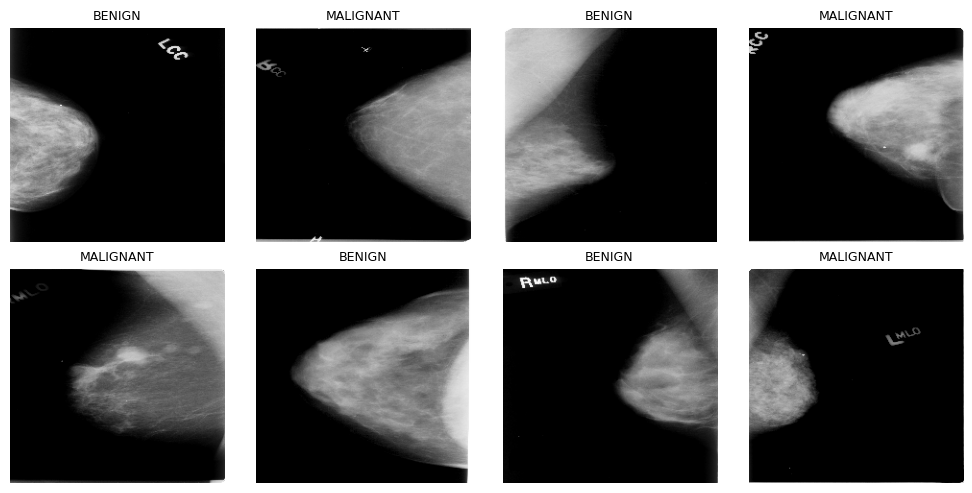

In [56]:
plt.figure(figsize=(10, 5))
for imgs, labs in train_ds.take(1):
    for j in range(8):
        ax = plt.subplot(2, 4, j+1)
        plt.imshow(imgs[j].numpy().astype("uint8"))
        plt.title("MALIGNANT" if labs[j] == 1 else "BENIGN", fontsize=9)
        plt.axis("off")
plt.tight_layout(); plt.show()

## A4. Model Architecture & Justification

**What:** Transfer learning: MobileNetV2 (pretrained on ImageNet, frozen) as
feature extractor, with a small trainable head outputting one probability
(malignant vs benign).

**Why:**
- **Binary classification** → sigmoid output, binary cross-entropy loss.
- **Small dataset (~2,100 train images)** → training from scratch would
  overfit; ImageNet features transfer well to X-ray texture.
- **MobileNetV2 specifically** → lightweight (2.3M params), fast on CPU, and
  a proven general-purpose feature extractor.
- **Preprocessing inside the model** → the saved file is self-contained;
  the Part B Streamlit app needs no extra scaling code.
- Grayscale mammograms are replicated to 3 channels for the pretrained
  backbone's RGB input. Only the small head trains in round 1.

In [57]:
inputs = layers.Input(shape=(224, 224, 3))

x = data_augment(inputs)            # training only
x = rescale(x)                      # 0-255 -> 0-1

base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base.trainable = False

x = base(x, training=False)         # frozen -> dropout off
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)   # P(malignant)

model = Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## A5. Training

**What:** Train the classification head for up to 15 epochs, monitoring the
validation loss.

**Why:**
- The dataset is nearly balanced (~54% malignant), so class weights are
  close to 1.0 — still passed for consistency and documented imbalance.
- EarlyStopping watches validation loss and restores the best weights,
  stopping when improvement flattens — prevents overfitting.

In [58]:
n_mal = int((tr["label"] == 1).sum())
n_ben = int((tr["label"] == 0).sum())
total = len(tr)
w = {0: total/(2*n_ben), 1: total/(2*n_mal)}
print("class weights:", {k: round(v, 3) for k, v in w.items()})

class weights: {0: 1.021, 1: 0.98}


In [ ]:
callbacks = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]

history = model.fit(train_ds, validation_data=val_ds,
                    epochs=15, class_weight=w, callbacks=callbacks)

Epoch 1/15
53/56 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step - accuracy: 0.5206 - loss: 0.7619

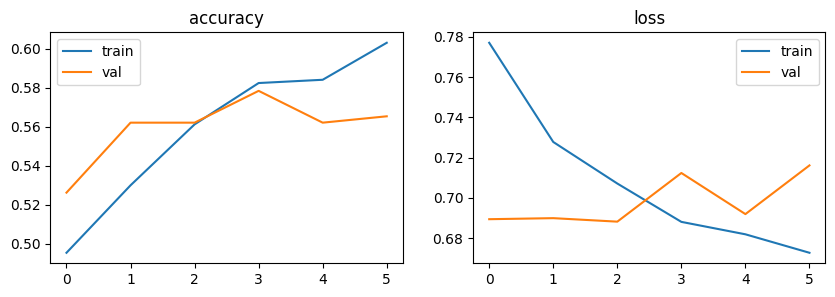

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
for i, m in enumerate(["accuracy", "loss"]):
    ax[i].plot(history.history[m], label="train")
    ax[i].plot(history.history["val_" + m], label="val")
    ax[i].set_title(m)
    ax[i].legend()
plt.show()

**Retraining with correct preprocessing:** MobileNetV2 expects inputs in
the range [-1, +1] (its native preprocess_input), not [0, 1]. Our first
round used plain rescaling, which misaligned the pretrained features and
capped accuracy near chance (~0.55). We rebuild with the official
preprocessing layer inside the model and retrain.

In [41]:
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

inputs = layers.Input(shape=(224, 224, 3))
x = data_augment(inputs)
x = layers.Lambda(preprocess)(x)          # correct: 0-255 -> [-1, +1]

base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base.trainable = False

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## A6. Evaluation & Results

**What:** One-time evaluation on the unseen test set. We report accuracy,
precision, recall and F1 per class, plus a confusion matrix. In this clinical
setting recall on MALIGNANT is the most important number: it measures how
many cancers the model catches — a false negative (missed cancer) is the
dangerous error, while a false positive costs an extra follow-up.

**Why not just accuracy:** on a medical screening task, a single accuracy
number can hide a model that misses the minority condition. The per-class
breakdown and confusion matrix show exactly where it errs.

              precision    recall  f1-score   support

      BENIGN      0.694     0.222     0.337       306
   MALIGNANT      0.491     0.885     0.632       260

    accuracy                          0.527       566
   macro avg      0.593     0.553     0.484       566
weighted avg      0.601     0.527     0.472       566



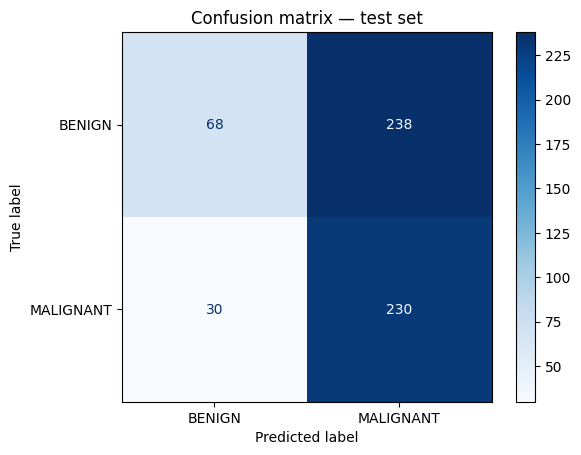

In [44]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X, Y = [], []
for imgs, labs in test_ds:
    X.append(imgs.numpy()); Y.append(labs.numpy())
X = np.concatenate(X); Y = np.concatenate(Y).astype(int).ravel()

probs = model.predict(X, verbose=0).ravel()
preds = (probs > 0.5).astype(int)

print(classification_report(Y, preds, target_names=["BENIGN", "MALIGNANT"], digits=3))

cm = confusion_matrix(Y, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["BENIGN", "MALIGNANT"])
disp.plot(cmap="Blues"); plt.title("Confusion matrix — test set"); plt.show()

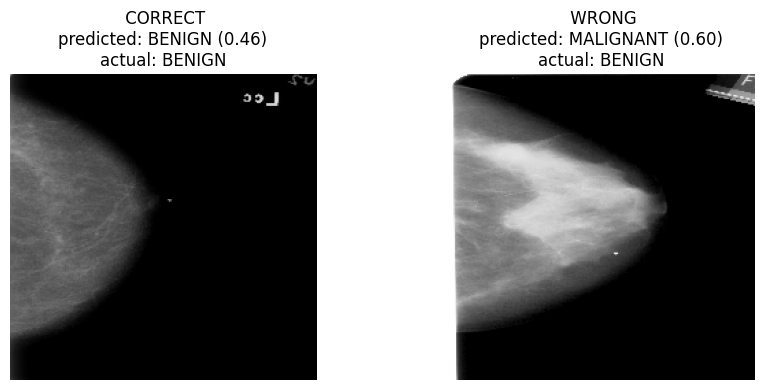

In [45]:
class_names = ["BENIGN", "MALIGNANT"]
correct_idx = np.where(preds == Y)[0][0]
wrong_idx   = np.where(preds != Y)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, idx, ok in [(axes[0], correct_idx, True), (axes[1], wrong_idx, False)]:
    ax.imshow(X[idx].astype("uint8"), cmap="gray")
    ax.set_title(f"{' CORRECT' if ok else ' WRONG'}\n"
                 f"predicted: {class_names[preds[idx]]} ({probs[idx]:.2f})\n"
                 f"actual: {class_names[Y[idx]]}")
    ax.axis("off")
plt.tight_layout(); plt.show()

## A7. Model Export

**What:** Save the trained model so the Part B portal can load it exactly.

**Preprocessing pipeline that MUST be reapplied at inference (matches Part B):**
1. Load image as RGB (grayscale mammograms are read and replicated to 3 channels)
2. Resize to 224×224
3. No manual rescaling — the model's internal Lambda layer maps 0–255 to [-1, +1]
   (MobileNetV2's expected range)

**File:** chest_xray… no — mammography_model.keras (Keras v3 format).


In [46]:
import tensorflow as tf
model.save("mammography_model.keras")
print("saved:", pathlib.Path("mammography_model.keras").exists(),
      "| tensorflow", tf.__version__)

saved: True | tensorflow 2.20.0


## A8. Limitations, Ethics & Next Steps

- **Generalisation limits:** trained on CBIS-DDSM cropped lesion views from
  a single US screening programme (1990s–2001 DDSM source). Performance on
  modern digital mammography, other populations, or full mammogram images
  is unverified.
- **False negatives vs false positives:** a missed cancer (false negative)
  can delay diagnosis; a false positive triggers unnecessary anxiety and
  follow-up imaging. Our threshold (0.5) could be tuned to favour recall.
- **Ethics:** this is a coursework prototype, not a diagnostic tool. It must
  never be used for medical decisions; any real system needs radiologist
  oversight, prospective validation, and regulatory review.
- **Next steps:** fine-tune more backbone layers with a low learning rate;
  use full mammograms with lesion masks; calibrate probabilities; external
  validation on an independent cohort.

In [21]:
print("train accuracy check:")
train_probs = model.predict(next(iter(train_ds.take(1)))[0], verbose=0)
print(train_probs[:10])

train accuracy check:
[[0.71728104]
 [0.5718348 ]
 [0.54371995]
 [0.8258757 ]
 [0.8370835 ]
 [0.62951005]
 [0.8846249 ]
 [0.57526726]
 [0.8028875 ]
 [0.7146743 ]]
